In [1]:
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled")
    except RuntimeError as e:
        print("Error enabling memory growth:", e)

Memory growth enabled


In [3]:
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.19.0


In [4]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [10]:
train_path = '/content/drive/MyDrive/chest_xray/train'
test_path = '/content/drive/MyDrive/chest_xray/test'
val_path = '/content/drive/MyDrive/chest_xray/val'

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

In [11]:
print("Loading data...")

train_datagen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess
)

training_set = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_set = test_datagen.flow_from_directory(
    test_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Loading data...
Found 5216 images belonging to 2 classes.
Found 1124 images belonging to 2 classes.


In [12]:
base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=IMAGE_SIZE + (3,))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x) # ResNet responds very well to BN after GAP
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
predictions = Dense(2, activation='softmax')(x)

model_resnet = Model(inputs=base_model.input, outputs=predictions)

In [13]:
model_resnet.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('resnet50v2_pneumonia.keras', save_best_only=True, monitor='val_loss')
]

print("Phase 1: Training Classification Head...")
history1 = model_resnet.fit(
    training_set,
    validation_data=test_set,
    epochs=10,
    callbacks=callbacks
)

Phase 1: Training Classification Head...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 2204s 13s/step - accuracy: 0.8444 - loss: 0.4760 - val_accuracy: 0.9262 - val_loss: 0.2127 - learning_rate: 0.0010
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 799ms/step - accuracy: 0.9292 - loss: 0.2196 - val_accuracy: 0.9244 - val_loss: 0.2000 - learning_rate: 0.0010
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 140s 858ms/step - accuracy: 0.9389 - loss: 0.1660 - val_accuracy: 0.9270 - val_loss: 0.1915 - learning_rate: 0.0010
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 800ms/step - accuracy: 0.9348 - loss: 0.1664 - val_accuracy: 0.9288 - val_loss: 0.1933 - learning_rate: 0.0010
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 145s 815ms/step - accuracy: 0.9445 - loss: 0.1480 - val_accuracy: 0.9386 - val_loss: 0.1721 - learning_rate: 0.0010
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 129s 793ms/step - accuracy: 0.9479 - loss: 0.1412 - val_accuracy: 0.9351 - val_loss: 0.1797 - learning_rate: 0.0010
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 703ms/step - accuracy:

In [14]:
print("Phase 2: Fine-Tuning deep layers...")

base_model.trainable = True
for layer in base_model.layers[:-50]: # Unfreeze deeper into ResNet
    layer.trainable = False

model_resnet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model_resnet.fit(
    training_set,
    validation_data=test_set,
    epochs=15,
    callbacks=callbacks
)

model_resnet.save('resnet50v2_pneumonia_final.h5')

Phase 2: Fine-Tuning deep layers...
Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 161s 838ms/step - accuracy: 0.8968 - loss: 0.2539 - val_accuracy: 0.9288 - val_loss: 0.1948 - learning_rate: 1.0000e-05
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 798ms/step - accuracy: 0.9443 - loss: 0.1586 - val_accuracy: 0.9342 - val_loss: 0.1749 - learning_rate: 1.0000e-05
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 129s 790ms/step - accuracy: 0.9474 - loss: 0.1454 - val_accuracy: 0.9377 - val_loss: 0.1625 - learning_rate: 1.0000e-05
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 129s 793ms/step - accuracy: 0.9530 - loss: 0.1303 - val_accuracy: 0.9333 - val_loss: 0.1610 - learning_rate: 1.0000e-05
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 797ms/step - accuracy: 0.9515 - loss: 0.1210 - val_accuracy: 0.9413 - val_loss: 0.1625 - learning_rate: 1.0000e-05
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 139s 856ms/step - accuracy: 0.9599 - loss: 0.1065 - val_accuracy: 0.9422 - val_loss: 0.1585 - learning_rate: 1.0000e-05
Epoc

Making predictions on the test set...
36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 535ms/step
Number of test samples: 1124
Number of predictions: 1124
Plotting Confusion Matrix...


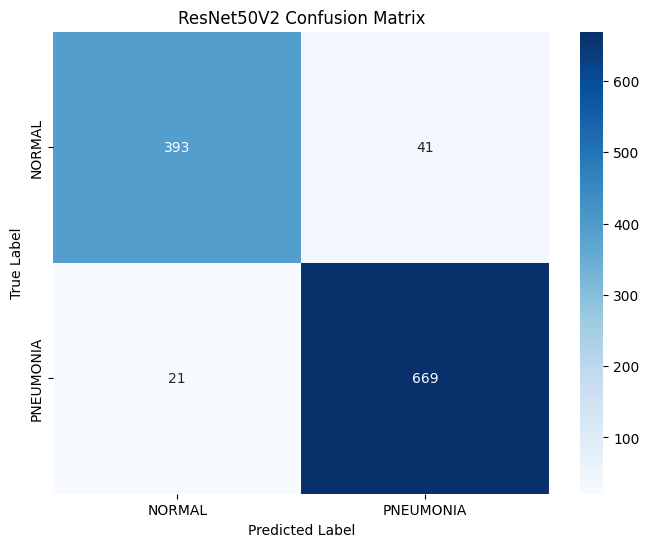

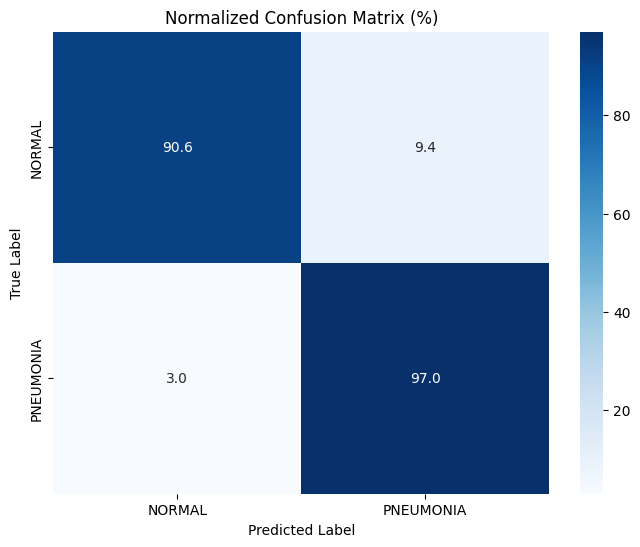

Plotting Training History...


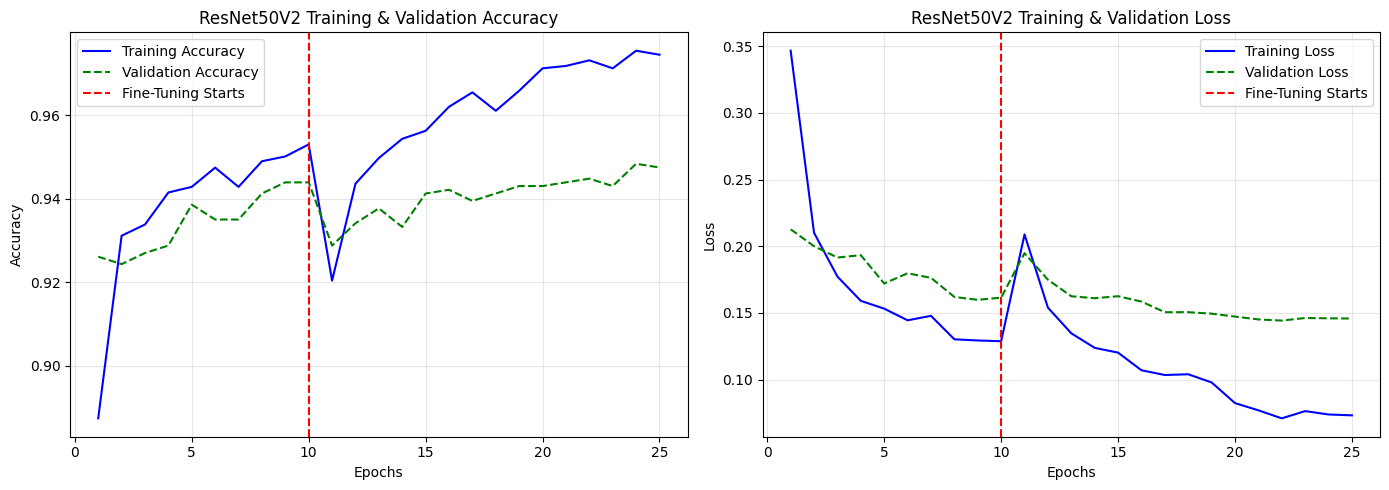

Plotting ROC Curves...


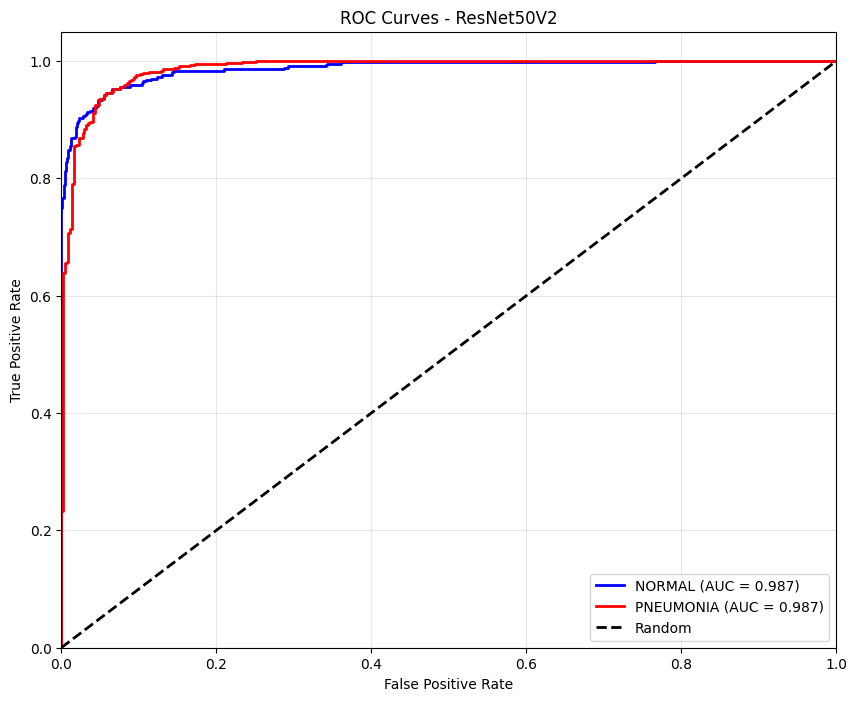

Plotting Precision-Recall Curves...


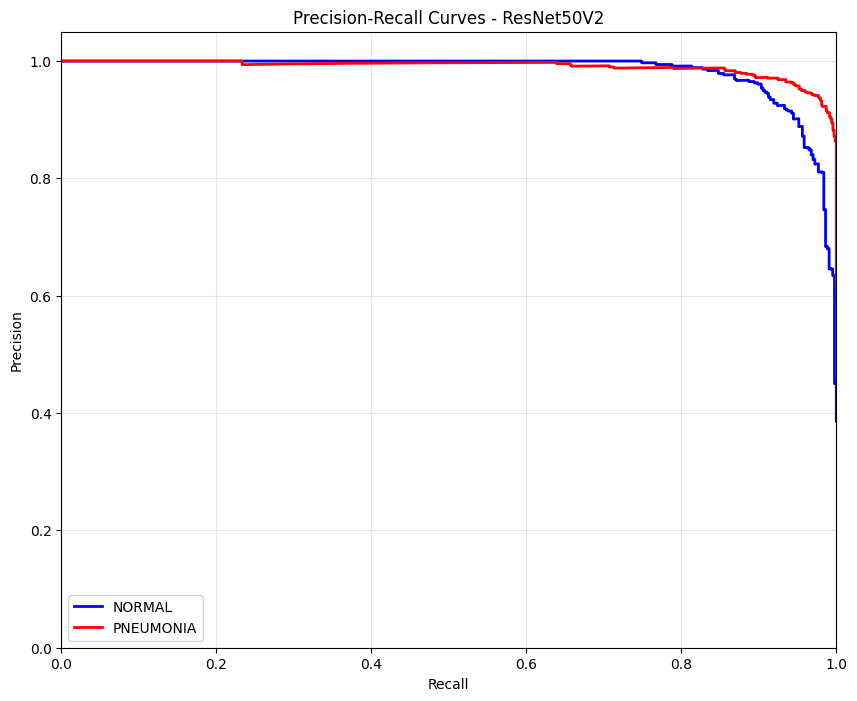

✅ All ResNet50V2 evaluations successfully plotted and saved to the 'results' folder!


In [17]:
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve

os.makedirs('results', exist_ok=True)

# --- Code to define y_true, y_pred, y_pred_proba, and class_names ---
print("Making predictions on the test set...")

y_pred_proba = model_resnet.predict(test_set)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = test_set.classes
class_names = list(test_set.class_indices.keys())

# Ensure y_true and y_pred have the same number of samples if using shuffle=True for test_set in flow_from_directory
# However, test_set was created with shuffle=False, so the order should match.
# Let's verify the number of samples.
print(f"Number of test samples: {len(y_true)}")
print(f"Number of predictions: {len(y_pred)}")
# ------------------------------------------------------------------

# 1. Confusion Matrix
print("Plotting Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('ResNet50V2 Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('results/resnet_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Normalized Confusion Matrix
plt.figure(figsize=(8, 6))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized * 100, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix (%)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('results/resnet_confusion_matrix_norm.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Training History Curves (combining both phases)
print("Plotting Training History...")
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'g--', label='Validation Accuracy')
plt.axvline(x=len(history1.history['accuracy']), color='r', linestyle='--', label='Fine-Tuning Starts')
plt.title('ResNet50V2 Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'g--', label='Validation Loss')
plt.axvline(x=len(history1.history['loss']), color='r', linestyle='--', label='Fine-Tuning Starts')
plt.title('ResNet50V2 Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/resnet_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. ROC Curves
print("Plotting ROC Curves...")
plt.figure(figsize=(10, 8))
colors = ['blue', 'red']
for i, (class_name, color) in enumerate(zip(class_names, colors)):
    y_true_bin = (y_true == i).astype(int)
    fpr, tpr, _ = roc_curve(y_true_bin, y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{class_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - ResNet50V2')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig('results/resnet_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Precision-Recall Curves
print("Plotting Precision-Recall Curves...")
plt.figure(figsize=(10, 8))
for i, (class_name, color) in enumerate(zip(class_names, colors)):
    y_true_bin = (y_true == i).astype(int)
    precision, recall, _ = precision_recall_curve(y_true_bin, y_pred_proba[:, i])
    plt.plot(recall, precision, color=color, lw=2, label=f'{class_name}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - ResNet50V2')
plt.legend(loc="lower left")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, alpha=0.3)
plt.savefig('results/resnet_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ All ResNet50V2 evaluations successfully plotted and saved to the 'results' folder!")

In [18]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

import pandas as pd
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_metrics = pd.DataFrame(report_dict).transpose()
print("\n================ Metrics Table ================")
print(df_metrics.round(4))
print("===============================================\n")

os.makedirs('results', exist_ok=True)
df_metrics.to_csv('results/resnet_metrics_table.csv')
print("✅ Metrics table saved to results/resnet_metrics_table.csv")

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.95      0.91      0.93       434
   PNEUMONIA       0.94      0.97      0.96       690

    accuracy                           0.94      1124
   macro avg       0.95      0.94      0.94      1124
weighted avg       0.94      0.94      0.94      1124


================ Metrics Table ================
              precision  recall  f1-score    support
NORMAL           0.9493  0.9055    0.9269   434.0000
PNEUMONIA        0.9423  0.9696    0.9557   690.0000
accuracy         0.9448  0.9448    0.9448     0.9448
macro avg        0.9458  0.9375    0.9413  1124.0000
weighted avg     0.9450  0.9448    0.9446  1124.0000

✅ Metrics table saved to results/resnet_metrics_table.csv
